---

<div align="center">
  <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg" width="80"/>
</div>

<h1 align="center">Aula 3: Outro Exemplo de Regressão Linear</h1>

<h3 align="center">PhD. in progress Samir Ramos</h3>

<div align="center">
  <img src="https://img.shields.io/badge/Python-3776AB?style=for-the-badge&logo=python&logoColor=white"/>
  <img src="https://img.shields.io/badge/Jupyter-F37626?style=for-the-badge&logo=jupyter&logoColor=white"/>
</div>

---

# Projeto 1: Crescimento de um App de Corridas e Capacidade de Servidores (AWS)

**Objetivo da parte 1 da aula:**

- Relembrar o que é **regressão linear** na prática.
- Trabalhar passo a passo o código Python (linha a linha).
- Medir a qualidade do modelo com **R², MAE, MSE, RMSE**.
- Usar o modelo para prever **quando** precisamos escalar servidores (AWS Auto Scaling).

1.3. Setup e leitura dos dados

In [2]:
import numpy as np          # biblioteca para cálculos numéricos (vetores, matrizes)
import pandas as pd         # biblioteca para trabalhar com tabelas (DataFrame)
import matplotlib.pyplot as plt  # biblioteca para gráficos
import matplotlib.dates as mdates  # ajuda a formatar datas nos gráficos
from datetime import timedelta     # para somar dias em datas
from pathlib import Path           # para trabalhar com caminhos de arquivos

======>>>>> VEJA O SLIDE DO PROFESSOR PARA EXPLICAÇÃO DETALHADA


In [3]:
# caminho do arquivo de dados (já gerado antes)
PATH_CSV = Path("data/rides_app.csv")

# ler o arquivo CSV em um DataFrame
df = pd.read_csv(PATH_CSV)

# mostrar as 5 primeiras linhas da tabela
df.head()

,date,rides_count
0,2025-01-01,5993
1,2025-01-02,4973
2,2025-01-03,6795
3,2025-01-04,8796
4,2025-01-05,5531


======>>>>> VEJA O SLIDE DO PROFESSOR PARA EXPLICAÇÃO DETALHADA

In [4]:
# informações gerais sobre o DataFrame: colunas, tipos, etc.
df.info()

# estatísticas básicas das colunas numéricas
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   date         180 non-null    str  
 1   rides_count  180 non-null    int64
dtypes: int64(1), str(1)
memory usage: 2.9 KB


,rides_count
count,180.000000
mean,27330.238889
std,13397.592570
min,4423.000000
25%,15588.500000
50%,27500.500000
75%,38208.250000
max,55190.000000


1.4. Tratando datas e criando days_since_launch

In [5]:
# converter a coluna 'date' para o tipo datetime (data de verdade)
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d")

# garantir que os dados estão na ordem da data (do mais antigo para o mais recente)
df = df.sort_values("date").reset_index(drop=True)

# pegar a primeira data do conjunto (dia zero)
dia_zero = df["date"].min()

# criar uma nova coluna com "dias desde o lançamento"
df["days_since_launch"] = (df["date"] - dia_zero).dt.days

df.head()

,date,rides_count,days_since_launch
0,2025-01-01,5993,0
1,2025-01-02,4973,1
2,2025-01-03,6795,2
3,2025-01-04,8796,3
4,2025-01-05,5531,4


1.5. Gráfico simples: corridas por dia

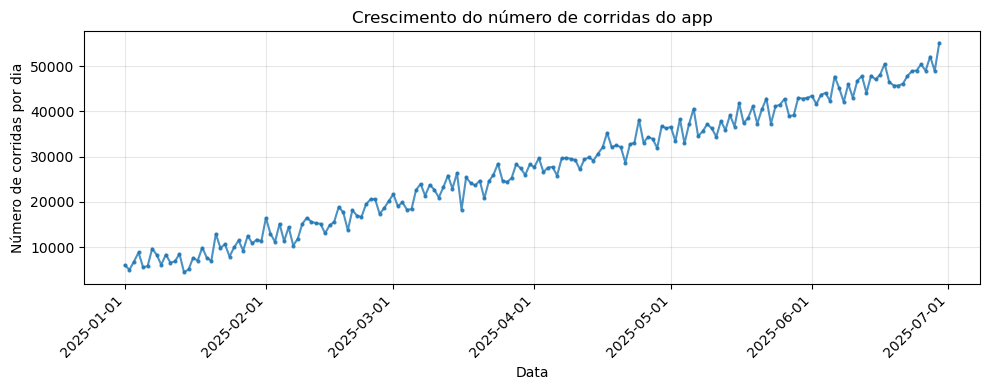

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))

# gráfico linha/pontos
ax.plot(df["date"], df["rides_count"], ".-", alpha=0.8, markersize=4)

ax.set_xlabel("Data")
ax.set_ylabel("Número de corridas por dia")
ax.set_title("Crescimento do número de corridas do app")

# formatar eixo x para mostrar datas legíveis
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

1.6. Montando X, y e a matriz para regressão linear

In [7]:
# X = dias desde o lançamento (feature)
X = df["days_since_launch"].to_numpy().reshape(-1, 1)

# y = número de corridas por dia (target)
y = df["rides_count"].to_numpy()

# número de observações (linhas)
n = len(y)

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (180, 1)
Formato de y: (180,)


In [8]:
# montar X_b: adicionamos uma coluna de 1s para representar o intercepto (beta0)
X_b = np.hstack([np.ones((n, 1)), X])

print("Primeiras linhas de X_b:")
print(X_b[:5, :])

Primeiras linhas de X_b:
[[1. 0.]
 [1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 4.]]


1.7. Equação normal – calculando β0 e β1

In [9]:
# Equação normal da regressão linear: 
# beta = (X_b^T X_b)^(-1) X_b^T y

beta = np.linalg.solve(X_b.T @ X_b, X_b.T @ y)

beta0 = beta[0]   # intercepto
beta1 = beta[1]   # coeficiente angular (crescimento por dia)

print("Parâmetros do modelo:")
print(f"  beta0 (intercepto)       = {beta0:.2f}")
print(f"  beta1 (corridas/dia/dia) = {beta1:.2f}")
print(f"Equação: rides = {beta0:.2f} + {beta1:.2f} * days_since_launch")

Parâmetros do modelo:
  beta0 (intercepto)       = 4546.69
  beta1 (corridas/dia/dia) = 254.56
Equação: rides = 4546.69 + 254.56 * days_since_launch


In [10]:
# calcular as predições do modelo
y_pred = X_b @ beta

1.8. Métricas: R², MAE, MSE, RMSE (em unidades reais)

In [11]:
# R²
ss_res = np.sum((y - y_pred) ** 2)           # soma dos quadrados dos resíduos
ss_tot = np.sum((y - y.mean()) ** 2)        # soma dos quadrados total
r2 = 1 - ss_res / ss_tot

# MAE (erro absoluto médio)
mae = np.mean(np.abs(y - y_pred))

# MSE (erro quadrático médio)
mse = np.mean((y - y_pred) ** 2)

# RMSE (raiz do erro quadrático médio)
rmse = np.sqrt(mse)

print(f"R²   = {r2:.4f}")
print(f"MAE  = {mae:.2f} corridas/dia")
print(f"MSE  = {mse:.2f} (corridas/dia)^2")
print(f"RMSE = {rmse:.2f} corridas/dia")

print("\nInterpretação:")
print(f"- R² = {r2:.3f} → {r2*100:.1f}% da variação do número de corridas é explicada pelo tempo.")
print(f"- MAE ≈ {mae:.0f} → o modelo erra, em média, cerca de {mae:.0f} corridas por dia.")
print(f"- RMSE ≈ {rmse:.0f} → erro típico de ~{rmse:.0f} corridas por dia (unidade real do problema).")

R²   = 0.9802
MAE  = 1482.80 corridas/dia
MSE  = 3534956.81 (corridas/dia)^2
RMSE = 1880.15 corridas/dia

Interpretação:
- R² = 0.980 → 98.0% da variação do número de corridas é explicada pelo tempo.
- MAE ≈ 1483 → o modelo erra, em média, cerca de 1483 corridas por dia.
- RMSE ≈ 1880 → erro típico de ~1880 corridas por dia (unidade real do problema).


1.9. Gráfico: dados reais + reta de regressão

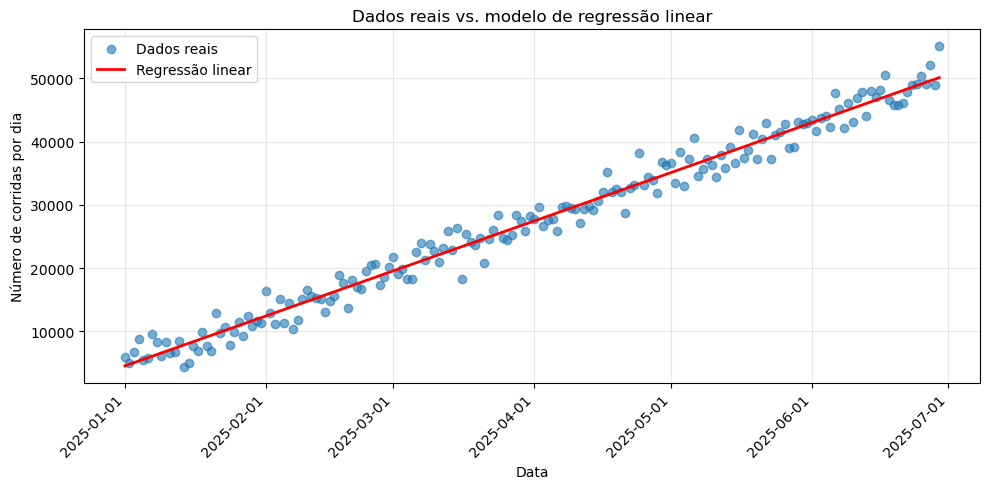

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(df["date"], y, alpha=0.6, label="Dados reais")
ax.plot(df["date"], y_pred, color="red", linewidth=2, label="Regressão linear")

ax.set_xlabel("Data")
ax.set_ylabel("Número de corridas por dia")
ax.set_title("Dados reais vs. modelo de regressão linear")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

1.10. Capacidade da instância EC2 e data para escalar

In [14]:
# limite de capacidade de uma instância (exemplo)
capacity_per_instance = 40000  # corridas/dia

rides_limit = capacity_per_instance

# queremos saber t_limit tal que:
#   rides_limit = beta0 + beta1 * t_limit
# então:
#   t_limit = (rides_limit - beta0) / beta1

t_limit = (rides_limit - beta0) / beta1

date_limit = dia_zero + timedelta(days=t_limit)

print("Planejamento de capacidade:")
print(f"- Limite de 1 instância: {rides_limit:.0f} corridas/dia")
print(f"- Dias desde o lançamento para chegar nesse limite: {t_limit:.1f} dias")
print(f"- Data aproximada para atingir esse limite: {date_limit.date()}")

Planejamento de capacidade:
- Limite de 1 instância: 40000 corridas/dia
- Dias desde o lançamento para chegar nesse limite: 139.3 dias
- Data aproximada para atingir esse limite: 2025-05-20


1.11. Mini-desafio guiado (se der tempo)

Troquem capacity_per_instance para 40.000 (80% do limite).

Em que data deveríamos planejar escalar, sendo conservadores?

---
## Apresentar o modelo de regressão linear

O modelo de regressão linear simples é:

$$y = \beta_0 + \beta_1 \cdot t$$

onde $t$ é o tempo (dias) e $y$ é a eficiência. Os parâmetros $\beta_0$ (intercepto) e $\beta_1$ (coeficiente angular) definem a reta que buscamos ajustar aos dados.

---
## Abordagem para ajustar parâmetros (maximizando R²)

Queremos escolher $\beta_0$ e $\beta_1$ de modo que o modelo se ajuste bem aos dados. Isso equivale a **minimizar a soma dos quadrados dos resíduos** (SSE):

$$\text{SSE} = \sum_i (y_i - \hat{y}_i)^2$$

Minimizar o SSE é equivalente a **maximizar o R²** (coeficiente de determinação). Para a regressão linear, existe **solução em forma fechada** pela **equação normal**:

$$\boldsymbol{\beta} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

com $\mathbf{X}$ incluindo uma coluna de 1s para o termo constante (intercepto).

---
## Apresentar resultados

### Métricas

O **R² (coeficiente de determinação)** mede quanto da variação de $y$ é explicada pelo modelo:

$$R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}$$

Valores próximos de 1 indicam bom ajuste; próximos de 0 indicam que o modelo não explica bem a variabilidade dos dados.

### Gráficos

Pontos = dados reais; reta = predição do modelo de regressão linear.

---
## Interpretação dos parâmetros e relação com ML mais complexo

### O que temos neste modelo
- **$\beta_0$ (intercepto):** valor esperado da eficiência quando o tempo é zero (início da série).
- **$\beta_1$ (coeficiente do tempo):** variação média da eficiência por dia. Se $\beta_1 < 0$, a eficiência tende a diminuir com o tempo (ex.: degradação); se $\beta_1 > 0$, tende a aumentar.

### Ligação com modelos de ML mais complexos
1. **Mesma ideia central:** encontrar **parâmetros** que minimizem o erro entre predição e valor real. Na regressão linear usamos a solução analítica; em redes neurais e outros modelos usamos **otimização iterativa** (ex.: gradiente descendente).
2. **Mais variáveis:** em vez de só tempo, podemos usar várias features (temperaturas, vazões, etc.) → **regressão linear múltipla** ou **modelos lineares generalizados**.
3. **Relações não lineares:** quando uma reta não descreve bem os dados, entram **polinômios**, **árvores de decisão**, **redes neurais** etc., que aprendem funções não lineares a partir dos dados.
4. **Treino e avaliação:** aqui ajustamos em todos os pontos; em ML é comum separar **treino** e **teste** para avaliar generalização, assim como em modelos mais complexos.

Assim, a regressão linear simples é a **base conceitual**: entrada → modelo (parâmetros) → saída predita; o que muda nos modelos complexos é a **forma do modelo** e o **método de aprendizado** dos parâmetros.